# MS_04 — Multi-Station Comparison

Loads B1/B2/B3 metrics for every station that has all three results files.
Produces MAE/R² horizon plots, cross-station heatmaps at h=24, and a summary table.

All figures go to `outputs/multistation/figures/`.
Summary CSV goes to `outputs/multistation/results/comparison_table_all_multistation.csv`.

In [1]:
import sys
sys.path.insert(0, '..')

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import ALL_STATIONS, HORIZONS, OUTPUTS_DIR, get_station_paths
from src.utils import ensure_dirs

sns.set_theme(style='whitegrid', palette='tab10')

MS_FIGURES_DIR = OUTPUTS_DIR / 'multistation' / 'figures'
MS_RESULTS_DIR = OUTPUTS_DIR / 'multistation' / 'results'
ensure_dirs(MS_FIGURES_DIR, MS_RESULTS_DIR)

print('Output dirs ready.')

Output dirs ready.


In [2]:
# Load metrics for all stations that have all three result files
station_metrics = {}  # station -> {'C1': df, 'C2': df, 'C3': df}

for station in ALL_STATIONS:
    paths = get_station_paths(station)
    files = {
        'C1': paths['results'] / 'C1_metrics.csv',
        'C2': paths['results'] / 'C2_metrics.csv',
        'C3': paths['results'] / 'C3_metrics.csv',
    }
    missing = [k for k, v in files.items() if not v.exists()]
    if missing:
        print(f'[WARN] {station} — missing {missing}, skipping')
        continue

    station_metrics[station] = {k: pd.read_csv(v) for k, v in files.items()}

print(f'Stations with complete results: {list(station_metrics.keys())}')

Stations with complete results: ['MzWarChrosci', 'MzOtwoBrzozo', 'MzWarWokalna', 'MzWarAlNiepo', 'MzLegZegrzyn', 'MzPiasPulask', 'MzWarBajkowa']


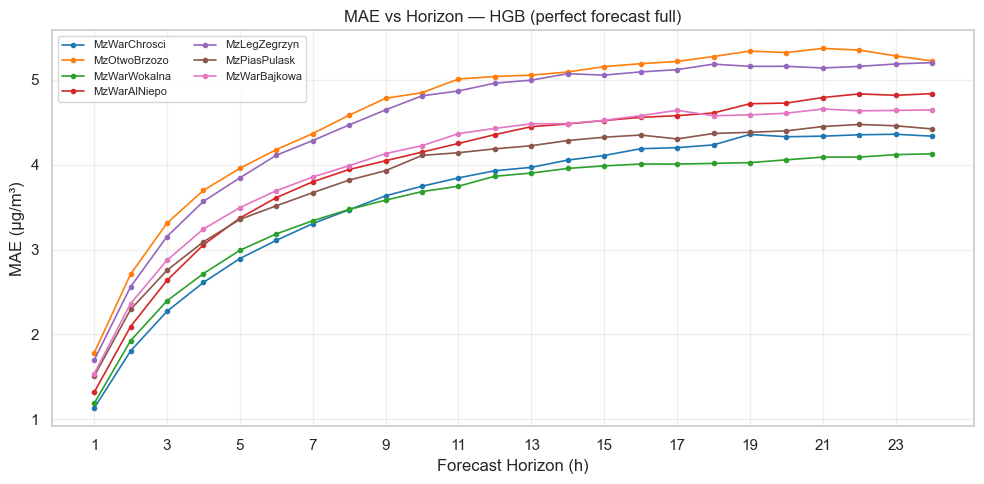

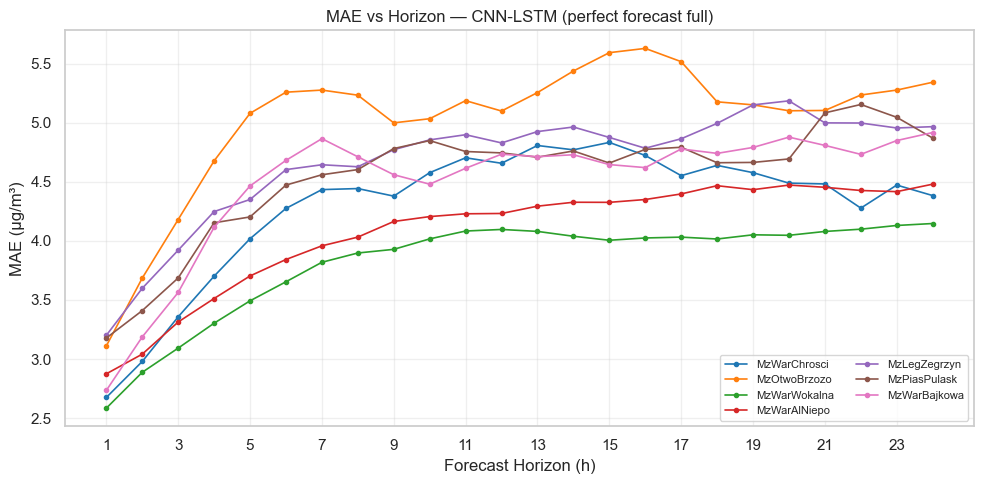

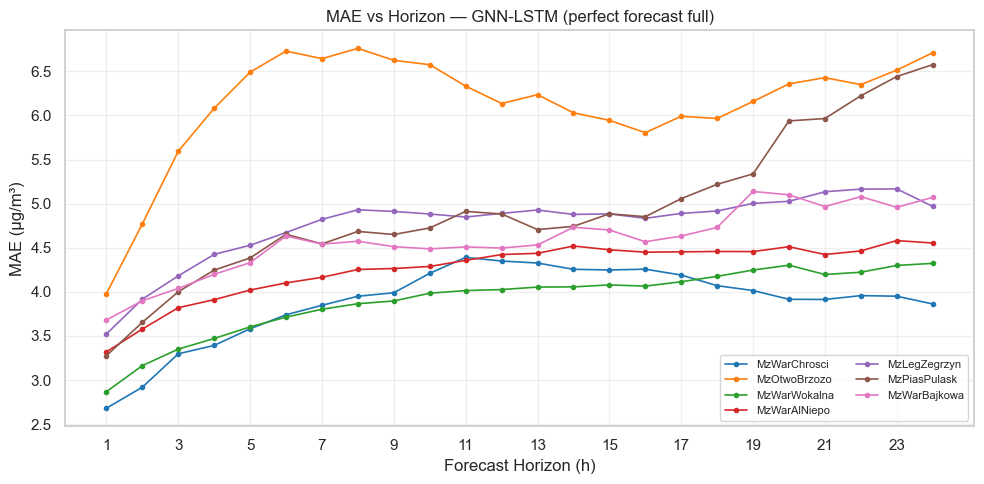

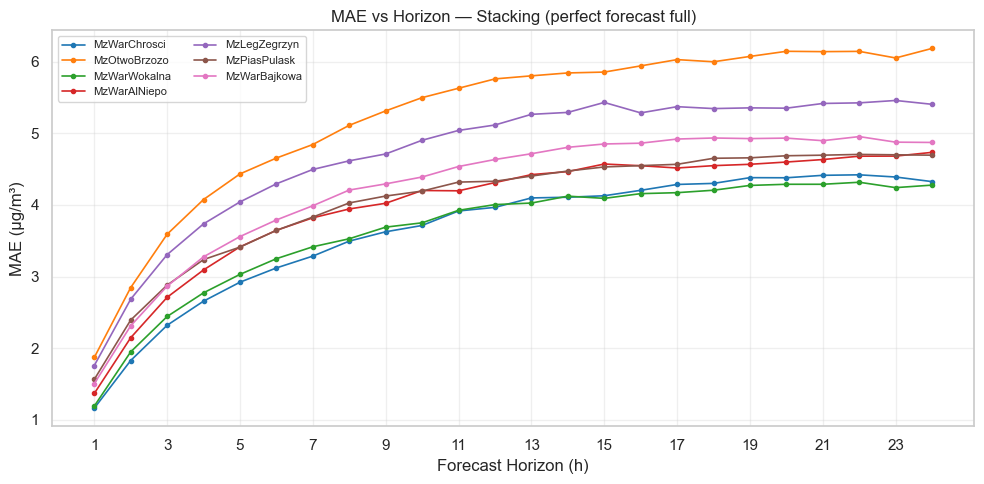

MAE horizon plots saved.


In [3]:
# Helper: extract metric series indexed by horizon for a given model label
def get_series(df, model_label_contains, metric, horizons=HORIZONS):
    sub = df[df['Model'].str.contains(model_label_contains, case=False)]
    sub = sub.set_index('Horizon')[metric].reindex(horizons)
    return sub


# ── MAE vs Horizon (one subplot per model family) ──────────────────────
families = [
    ('C1_HGB_pfxf', 'C1', 'HGB (perfect forecast full)'),
    ('C2_CNN_LSTM_pfxf', 'C2', 'CNN-LSTM (perfect forecast full)'),
    ('C3_GNN_LSTM_pfxf', 'C3_GNN', 'GNN-LSTM (perfect forecast full)'),
    ('C3_Stacking_pfxf', 'C3_Stack', 'Stacking (perfect forecast full)'),
]

for contains, tag, title in families:
    fig, ax = plt.subplots(figsize=(10, 5))
    for station, dfs in station_metrics.items():
        key = 'C3' if 'C3' in tag else tag[:2]
        df = dfs[key]
        s = get_series(df, contains, 'MAE')
        ax.plot(s.index, s.values, marker='o', markersize=3, linewidth=1.2, label=station)
    ax.set_xlabel('Forecast Horizon (h)')
    ax.set_ylabel('MAE (µg/m³)')
    ax.set_title(f'MAE vs Horizon — {title}')
    ax.set_xticks(range(1, 25, 2))
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(MS_FIGURES_DIR / f'mae_horizon_{tag}.png', bbox_inches='tight')
    plt.show()

print('MAE horizon plots saved.')

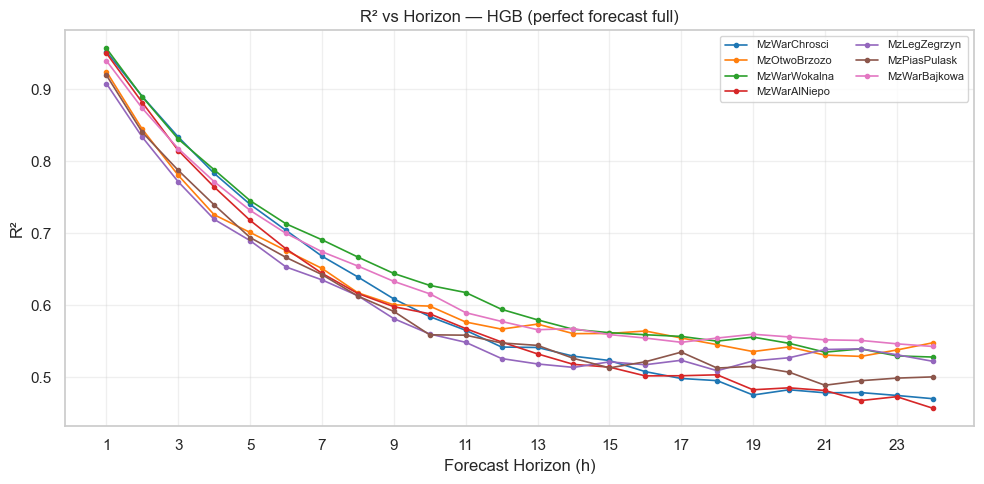

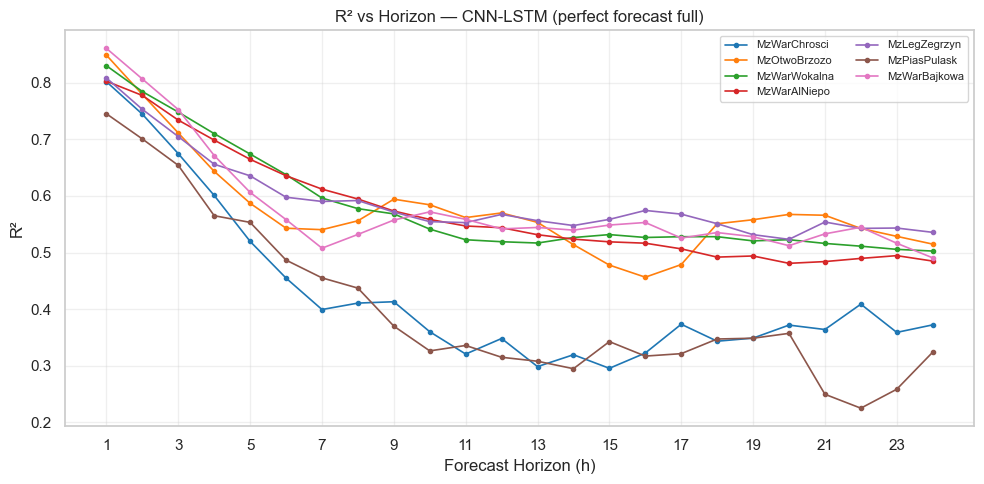

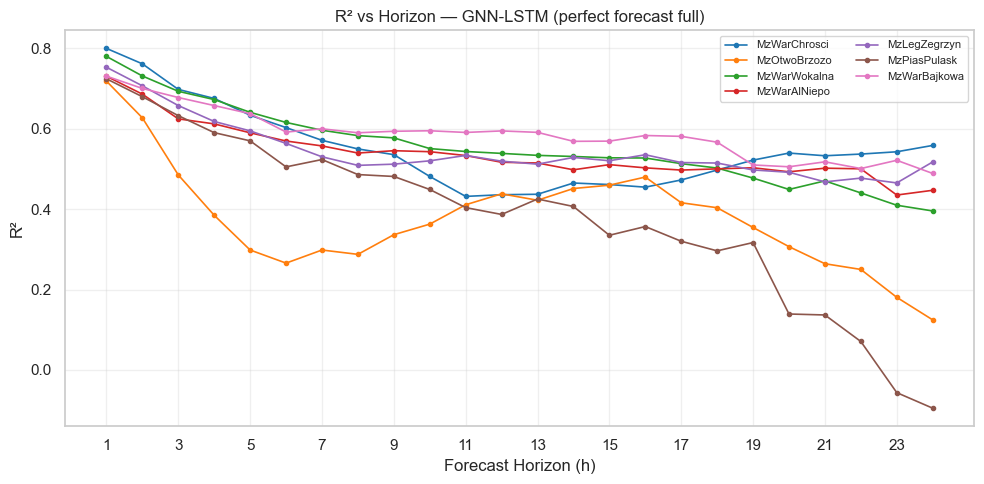

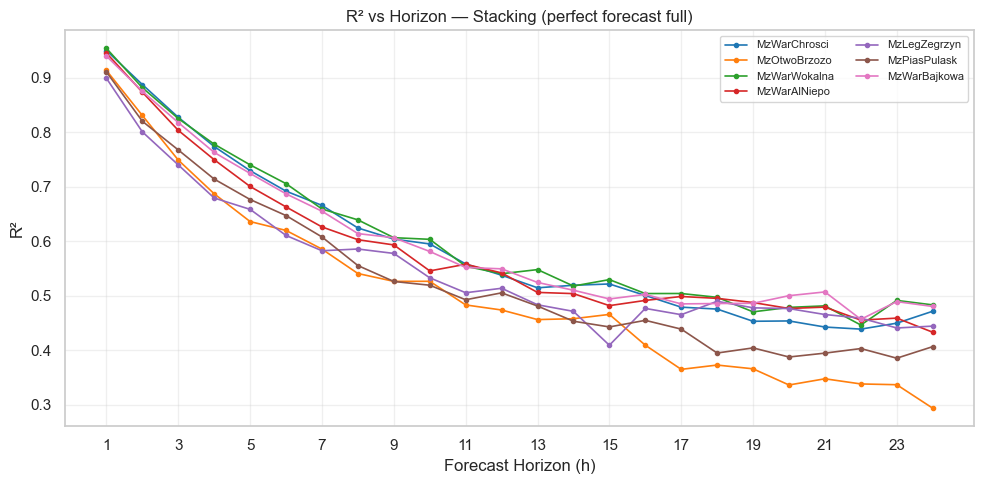

R² horizon plots saved.


In [4]:
# ── R² vs Horizon ──────────────────────────────────────────────────────
for contains, tag, title in families:
    fig, ax = plt.subplots(figsize=(10, 5))
    for station, dfs in station_metrics.items():
        key = 'C3' if 'C3' in tag else tag[:2]
        df = dfs[key]
        s = get_series(df, contains, 'R2')
        ax.plot(s.index, s.values, marker='o', markersize=3, linewidth=1.2, label=station)
    ax.set_xlabel('Forecast Horizon (h)')
    ax.set_ylabel('R²')
    ax.set_title(f'R² vs Horizon — {title}')
    ax.set_xticks(range(1, 25, 2))
    ax.legend(fontsize=8, ncol=2)
    ax.grid(alpha=0.3)
    fig.tight_layout()
    fig.savefig(MS_FIGURES_DIR / f'r2_horizon_{tag}.png', bbox_inches='tight')
    plt.show()

print('R² horizon plots saved.')

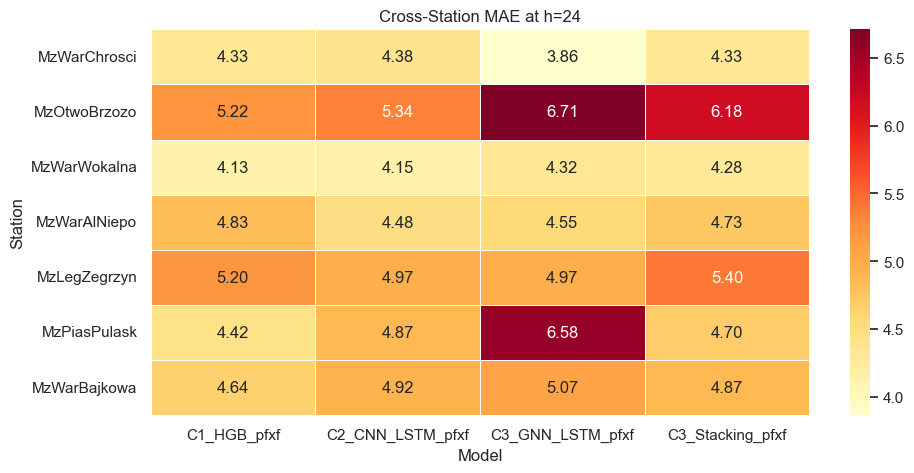

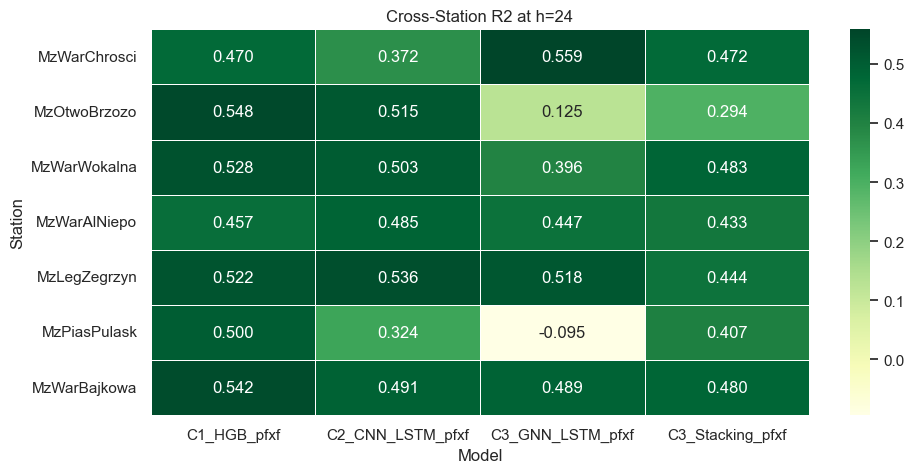

Heatmaps saved.


In [5]:
# ── Cross-station heatmaps at h=24 ────────────────────────────────────
model_cols = [
    ('C1_HGB_pfxf',        'C1',  'C1_HGB_pfxf'),
    ('C2_CNN_LSTM_pfxf',   'C2',  'C2_CNN_LSTM_pfxf'),
    ('C3_GNN_LSTM_pfxf',   'C3',  'C3_GNN_LSTM_pfxf'),
    ('C3_Stacking_pfxf',   'C3',  'C3_Stacking_pfxf'),
]

stations_ordered = list(station_metrics.keys())

def build_heatmap_df(metric, horizon=24):
    rows = {}
    for station in stations_ordered:
        dfs = station_metrics[station]
        row = {}
        for contains, key, col_name in model_cols:
            sub = dfs[key]
            val = sub[(sub['Model'].str.contains(contains, case=False)) & (sub['Horizon'] == horizon)][metric]
            row[col_name] = val.values[0] if len(val) > 0 else np.nan
        rows[station] = row
    return pd.DataFrame(rows).T

for metric, cmap, fmt in [('MAE', 'YlOrRd', '.2f'), ('R2', 'YlGn', '.3f')]:
    heat_df = build_heatmap_df(metric, horizon=24)
    fig, ax = plt.subplots(figsize=(10, max(4, len(stations_ordered) * 0.7)))
    sns.heatmap(heat_df, annot=True, fmt=fmt, cmap=cmap, ax=ax, linewidths=0.5)
    ax.set_title(f'Cross-Station {metric} at h=24')
    ax.set_xlabel('Model')
    ax.set_ylabel('Station')
    fig.tight_layout()
    fig.savefig(MS_FIGURES_DIR / f'heatmap_{metric.lower()}_h24.png', bbox_inches='tight')
    plt.show()

print('Heatmaps saved.')

In [6]:
# ── Summary table: best model per station at key horizons ─────────────
KEY_HORIZONS = [1, 6, 12, 24]
summary_rows = []

for station in stations_ordered:
    dfs = station_metrics[station]
    for h in KEY_HORIZONS:
        candidates = []
        for contains, key, col_name in model_cols:
            sub = dfs[key]
            row = sub[(sub['Model'].str.contains(contains, case=False)) & (sub['Horizon'] == h)]
            if len(row) > 0:
                candidates.append((col_name, row['MAE'].values[0], row['R2'].values[0]))
        if candidates:
            best = min(candidates, key=lambda x: x[1])
            summary_rows.append({
                'Station': station, 'Horizon': h,
                'Best_Model': best[0], 'Best_MAE': best[1], 'Best_R2': best[2],
            })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# Save all metrics combined
all_rows = []
for station in stations_ordered:
    for key, df in station_metrics[station].items():
        all_rows.append(df.assign(Station=station) if 'Station' not in df.columns else df)
all_df = pd.concat(all_rows, ignore_index=True)
all_df.to_csv(MS_RESULTS_DIR / 'comparison_table_all_multistation.csv', index=False)
print(f'\nSaved comparison_table_all_multistation.csv ({len(all_df)} rows)')

     Station  Horizon       Best_Model  Best_MAE  Best_R2
MzWarChrosci        1      C1_HGB_pfxf    1.1327   0.9524
MzWarChrosci        6      C1_HGB_pfxf    3.1078   0.7039
MzWarChrosci       12      C1_HGB_pfxf    3.9273   0.5417
MzWarChrosci       24 C3_GNN_LSTM_pfxf    3.8626   0.5587
MzOtwoBrzozo        1      C1_HGB_pfxf    1.7824   0.9246
MzOtwoBrzozo        6      C1_HGB_pfxf    4.1757   0.6758
MzOtwoBrzozo       12      C1_HGB_pfxf    5.0363   0.5666
MzOtwoBrzozo       24      C1_HGB_pfxf    5.2190   0.5476
MzWarWokalna        1      C1_HGB_pfxf    1.1881   0.9569
MzWarWokalna        6      C1_HGB_pfxf    3.1838   0.7130
MzWarWokalna       12      C1_HGB_pfxf    3.8627   0.5941
MzWarWokalna       24      C1_HGB_pfxf    4.1263   0.5278
MzWarAlNiepo        1      C1_HGB_pfxf    1.3191   0.9502
MzWarAlNiepo        6      C1_HGB_pfxf    3.6108   0.6782
MzWarAlNiepo       12 C2_CNN_LSTM_pfxf    4.2323   0.5439
MzWarAlNiepo       24 C2_CNN_LSTM_pfxf    4.4803   0.4849
MzLegZegrzyn  